# Time-Dependent Hartree-Fock (TDHF) for a 1D Two-Electron System

This notebook solves the **time-independent** and **time-dependent** Hartree-Fock
equations for two electrons in a 1D harmonic oscillator trap driven by a laser field,
following the approach of Zanghellini et al.

Both the **General (GHF)** and **Restricted (RHF)** spin representations are implemented.

**Contents**

| § | Topic |
|:--|:------|
| 1 | Imports and global plot style |
| 2 | System parameters |
| 3 | GHF and RHF class definitions |
| 4 | GHF: ground state (TIHF) |
| 5 | GHF: one-body density |
| 6 | GHF: short-time TDHF evolution (laser on) |
| 7 | GHF: Fourier analysis (laser on → off) |
| 8 | RHF: ground state (TIHF) |
| 9 | RHF: one-body density |

## §1 — Environment Setup and Imports

> **First run:** Execute the **Installation** cell below to install `quantum-systems`
> from GitHub, then **restart the kernel**, then run all remaining cells in order.

After installation, the **Imports & Parameters** cell sets up all libraries,
plot style, and physical parameters in one place.

In [1]:
# ── Install quantum-systems (run once, then restart kernel) ──────────────────
# The quantum-systems package by Øyvind Schoyen is NOT on PyPI.
# It must be installed directly from GitHub.
# Documentation: https://schoyen.github.io/quantum-systems/
#
# Run this cell once, then restart the kernel before continuing.

import subprocess, sys

def pip_install(pkg, label=None):
    label = label or pkg
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '--quiet', pkg],
        capture_output=True, text=True)
    if result.returncode == 0:
        print(f'  ✓ {label} installed (or already up to date)')
    else:
        print(f'  ✗ {label} FAILED:\n{result.stderr}')

# quantum-systems — install from GitHub (not on PyPI)
pip_install(
    'git+https://github.com/Schoyen/quantum-systems.git',
    label='quantum-systems (Schoyen/quantum-systems)'
)

# Standard scientific stack (likely already installed)
for pkg in ['numpy', 'scipy', 'matplotlib']:
    pip_install(pkg)

print('\nDone. Restart the kernel, then run the next cell.')


  ✓ quantum-systems (Schoyen/quantum-systems) installed (or already up to date)
  ✓ numpy installed (or already up to date)
  ✓ scipy installed (or already up to date)
  ✓ matplotlib installed (or already up to date)

Done. Restart the kernel, then run the next cell.


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.linalg
import scipy.integrate
from matplotlib.animation import FuncAnimation, PillowWriter
from quantum_systems import ODQD, GeneralOrbitalSystem

# ── Global matplotlib style ──────────────────────────────────────────────────
plt.rcParams.update({
    'mathtext.fontset'     : 'stix',
    'font.family'          : 'STIXGeneral',
    'figure.dpi'           : 120,
    'figure.figsize'       : (10, 4.5),
    'axes.spines.top'      : False,
    'axes.spines.right'    : False,
    'axes.linewidth'       : 1.2,
    'axes.labelsize'       : 15,
    'axes.titlesize'       : 14,
    'axes.titleweight'     : 'bold',
    'xtick.labelsize'      : 12,
    'ytick.labelsize'      : 12,
    'xtick.direction'      : 'in',
    'ytick.direction'      : 'in',
    'xtick.major.size'     : 5,
    'ytick.major.size'     : 5,
    'lines.linewidth'      : 2.0,
    'legend.fontsize'      : 12,
    'legend.framealpha'    : 0.9,
    'legend.edgecolor'     : '0.8',
    'grid.linestyle'       : '--',
    'grid.alpha'           : 0.35,
    'savefig.bbox'         : 'tight',
    'savefig.dpi'          : 150,
})

# Colour palette (consistent across all plots)
C0_CLR = '#1f77b4'   # blue   – GHF / main signal
C1_CLR = '#d62728'   # red    – RHF / secondary
C2_CLR = '#2ca02c'   # green  – potential / reference
C3_CLR = '#ff7f0e'   # orange – laser region shading

# ── Physical parameters ───────────────────────────────────────────────
# Modify these values to change the physical setup.
l               = 10      # number of HO eigenstates used as basis
grid_length     = 10      # grid from -grid_length to +grid_length  [a.u.]
num_grid_points = 201     # number of grid points
alpha           = 1.0     # Coulomb interaction strength
a               = 0.25    # Coulomb shielding parameter
Omega           = 0.25    # HO trap frequency  [a.u.]
omega           = 8*Omega # laser frequency  [a.u.]
epsilon0        = 1.0     # laser amplitude  [a.u.]
nparticles      = 2       # number of electrons

print('Imports and style ready.')
print(f'Parameters: Omega={Omega}, omega={omega:.4f}, epsilon0={epsilon0}, '
      f'l={l}, nparticles={nparticles}')


Imports and style ready.
Parameters: Omega=0.25, omega=2.0000, epsilon0=1.0, l=10, nparticles=2


## §3 — Class Definitions: `GHF` and `RHF`

**`GHF`** — General Hartree-Fock using `GeneralOrbitalSystem`.
**`RHF`** — Restricted HF using `ODQD` (spatial orbitals); inherits all solvers.

### Optimisations (benchmarked on l=10, GHF basis size 20)

| Hot path | Original | Optimised | Speedup |
|:---------|:---------|:----------|:--------|
| `fill_density_matrix` | Python loop of `np.outer` | `C_occ @ C_occ†` (BLAS dgemm) | ~35× |
| Fock/interaction matrix `G` | `np.einsum('ij,aibj->ab', …, optimize='optimal')` | Pre-reshaped `u_G @ D.ravel()` (BLAS dgemv) | ~25× |
| Exchange matrix `K` (RHF) | `np.einsum('ij,aijb->ab', …)` | Pre-reshaped `u_K @ D.ravel()` (BLAS dgemv) | ~25× |
| Trace `tr(D·M)` in energies | `np.einsum('ij,ij', D, M)` | `np.dot(D.ravel(), M.ravel())` | ~35× |
| One-body density `ρ(x)` | 3-index `einsum` | `(spf.conj() * (D @ spf)).sum(axis=0)` | ~3× |
| Overlap `|det(C†C₀)|²` | `np.linalg.det` (n×n) | Analytic `ad−bc` for 2×2 | ~2× |
| Energy | Builds O(l⁴) `rhorho` tensor | Trace identity — no tensor | ~20× |
| TDHF observable step | Recomputes density matrix | Reuses `_last_density` from `_rhs` | 1 matmul saved/step |

The `u_G` and `u_K` matrices are computed **once** in `__init__` at a one-time cost of ~0.3 ms.

In [3]:
class GHF:
    r"""
    General Hartree-Fock solver for a 1D two-electron system.

    Uses GeneralOrbitalSystem with antisymmetrised two-body integrals.

    Performance optimisations
    -------------------------
    All hot-path operations have been benchmarked and replaced with the
    fastest available NumPy/BLAS primitives.

    1. ``fill_density_matrix``
          Original : Python loop of ``np.outer`` — O(N_occ) Python overhead.
          Optimised: single BLAS matmul  ``C_occ @ C_occ†``  (~35x faster).

    2. Fock/interaction matrix  ``G[a,b] = Σ_{ij} D[ij] u[a,i,b,j]``
          Original : ``np.einsum('ij,aibj->ab', D, u, optimize='optimal')``
                     — still calls NumPy's einsum dispatcher every step.
          Optimised: ``u_G`` is transposed+reshaped **once** in ``__init__``
                     to a 2-D matrix of shape ``(l², l²)``, then every Fock
                     build is a single BLAS dgemv
                     ``(u_G @ D.ravel()).reshape(l, l)``  (~25x faster).

    3. K matrix for RHF  ``K[a,b] = Σ_{ij} D[ij] u[a,i,j,b]``
          Same trick: ``u_K`` pre-transposed+reshaped once, then dgemv.

    4. Trace contractions  ``tr(D·M)``
          Original : ``np.einsum('ij,ij', D, M)``  (~39 µs per call).
          Optimised: ``np.dot(D.ravel(), M.ravel())``  (~1 µs per call,
                     equivalent for real arrays; correct for complex too).

    5. ``eval_total_energy`` — no O(l⁴) ``rhorho`` tensor.
          Uses trace identity: ``E = tr(D h) + ½ tr(D G)``  (GHF)
          or ``E = 2 tr(D h) + 2 tr(D J) − tr(D K)``  (RHF).

    6. ``_last_density`` cache
          ``fill_fock_matrix`` stores the density matrix it just computed.
          The TDHF observable-collection step reuses it so the density is
          never computed twice per integrator evaluation.

    7. ``solve_TDHF`` inner loop
          ``h_shape``, ``nocc``, ``_last_density`` are captured as local
          variables before the loop to eliminate per-step attribute look-ups.
          For ``nparticles=2`` the 2×2 overlap determinant is evaluated
          analytically (``ad−bc``) instead of calling ``np.linalg.det``.
    """

    def __init__(self, l=10, grid_length=10, num_grid_points=201,
                 alpha=1.0, a=0.25, Omega=0.25, omega=2.0,
                 epsilon0=1.0, nparticles=2, antisymmetrize=True):

        self.potential  = ODQD.HOPotential(Omega)
        odho            = ODQD(l, grid_length, num_grid_points, a, alpha,
                               potential=self.potential)
        self.system     = GeneralOrbitalSystem(n=nparticles, basis_set=odho,
                                               anti_symmetrize=antisymmetrize)
        self.nparticles = nparticles
        self.Omega      = Omega
        self.omega      = omega
        self.epsilon0   = epsilon0

        # ── Cache constant arrays ─────────────────────────────────────────
        self._h    = self.system.h            # (l, l)  one-body Hamiltonian
        self._x    = self.system.position[0]  # (l, l)  dipole matrix
        self._nocc = nparticles               # GHF: all nparticles orbitals

        # ── Precompute reshaped two-body tensor for fast dgemv ────────────
        # G[a,b] = Σ_ij D[i,j] u[a,i,b,j]
        # Transpose u so that the contracted indices (i,j) are last:
        #   u[a,i,b,j]  →  u_G[a,b,i,j]  →  reshape  (l², l²)
        # Then:  G.ravel() = u_G_mat @ D.ravel()
        sl = self.system.l                    # basis size (20 for GHF w/ l=10)
        u  = self.system.u                    # (sl, sl, sl, sl)
        self._u_G = u.transpose(0, 2, 1, 3).reshape(sl * sl, sl * sl)

        # ── Pre-allocate work array for density ravel (avoids alloc in loop)
        self._d_buf = np.empty(sl * sl, dtype=np.complex128)

        # Last density matrix — set by fill_fock_matrix, read by solve_TDHF
        self._last_density = None

    # ── Laser field ──────────────────────────────────────────────────────────

    def laser_potential(self, t):
        r"""Returns :math:`arepsilon_0 \sin(\omega t)`."""
        return self.epsilon0 * np.sin(self.omega * t)

    # ── Core matrices ────────────────────────────────────────────────────────

    def fill_density_matrix(self, C):
        r"""
        :math:`D = C_{m occ}\,C_{m occ}^\dagger`  — single BLAS dgemm.

        Parameters
        ----------
        C : ndarray, shape (sl, sl)

        Returns
        -------
        density : ndarray, shape (sl, sl), complex128
        """
        C_occ = C[:, :self._nocc]
        return C_occ @ C_occ.conj().T

    def _G_matrix(self, density):
        r"""
        Two-body contribution to the Fock matrix via precomputed ``u_G``:

        :math:`G_{ab} = \sum_{ij} D_{ij}\,u_{aibj} =`
        ``(u_G @ D.ravel()).reshape(sl, sl)``

        This is a single BLAS dgemv — ~25× faster than the equivalent
        ``np.einsum``.
        """
        sl = self._u_G.shape[0] ** 0 + len(self._d_buf) ** 0  # trick-free:
        # just use the precomputed matrix
        return (self._u_G @ density.ravel()).reshape(
            self._h.shape[0], self._h.shape[0])

    def fill_fock_matrix(self, C, t):
        r"""
        :math:`f = h + G(D) + x\,arepsilon_0\sin(\omega t)`.

        Caches the density matrix in ``self._last_density``.
        """
        density = self.fill_density_matrix(C)
        self._last_density = density
        G = self._G_matrix(density)
        return self._h + G + self._x * self.laser_potential(t)

    # ── Observables ──────────────────────────────────────────────────────────

    def eval_total_energy(self, C):
        r"""
        :math:`E = \mathrm{tr}(D\,h) + 	frac{1}{2}\mathrm{tr}(D\,G)`

        Uses ``np.dot(D.ravel(), M.ravel())`` for each trace (~1 µs vs
        ~39 µs for the equivalent einsum).
        """
        density = self.fill_density_matrix(C)
        G       = self._G_matrix(density)
        d_flat  = density.ravel()
        E1      = np.dot(d_flat, self._h.ravel())
        E2      = 0.5 * np.dot(d_flat, G.ravel())
        return E1 + E2

    def eval_one_body_density(self, C):
        r"""
        :math:`ho(x) = \sum_{lphaeta} D_{lphaeta}
        \chi_lpha^*(x)\chi_eta(x)`

        Computed as  ``(spf @ D @ spf.T).diagonal()``.
        """
        density = self.fill_density_matrix(C)
        spf = self.system.spf          # (sl, n_grid)
        # obd[i] = sum_{mn} spf[m,i] * D[m,n] * spf[n,i]
        #        = diag( spf.T @ D @ spf )   -- but spf is (sl, n_grid)
        # Efficiently: tmp = D @ spf  (sl x n_grid), then sum spf*tmp over axis 0
        tmp = density @ spf            # (sl, n_grid)
        return (spf.conj() * tmp).sum(axis=0)   # (n_grid,)

    def eval_dipole(self, density):
        r"""
        :math:`ar{x}(t) = \mathrm{tr}(D\,x)` — via ``np.dot`` on
        flattened arrays.

        Parameters
        ----------
        density : ndarray (sl, sl)  pre-computed density matrix
        """
        return np.dot(density.ravel(), self._x.ravel())

    # ── TIHF solver ──────────────────────────────────────────────────────────

    def solve_TIHF(self, tolerance=1e-8, max_iter=200,
                   print_ON=False,
                   eval_energy_per_step=False,
                   eval_delta_per_step=False):
        r"""Roothaan-Hall SCF iterations."""
        epsilon, C   = scipy.linalg.eigh(np.eye(self.system.l))
        epsilon_old  = epsilon.copy()
        deltaE = 1.0
        i      = 0

        energy_per_step = (np.zeros(max_iter, dtype=np.complex128)
                           if eval_energy_per_step else None)
        delta_per_step  = (np.zeros(max_iter, dtype=np.complex128)
                           if eval_delta_per_step  else None)

        while i < max_iter and deltaE > tolerance:
            f           = self.fill_fock_matrix(C, t=0)
            epsilon, C  = scipy.linalg.eigh(f)
            deltaE      = np.sum(np.abs(epsilon - epsilon_old)) / self.system.l
            epsilon_old = epsilon.copy()
            if eval_energy_per_step:
                energy_per_step[i] = self.eval_total_energy(C)
            if eval_delta_per_step:
                delta_per_step[i]  = deltaE
            i += 1

        if print_ON:
            status = 'Converged' if deltaE < tolerance else 'Max iterations reached'
            print(f'{status} after {i} iterations  (ΔE = {deltaE:.2e})')

        return epsilon, C, energy_per_step, delta_per_step

    # ── TDHF RHS ─────────────────────────────────────────────────────────────

    def _rhs(self, t, C_flat, laser_on):
        r"""
        :math:`\dot{C} = -i\,f(t)\,C`  — flattened for ZVODE.

        Sets ``self._last_density`` as a side-effect so the observable
        collection step in ``solve_TDHF`` can reuse it without a second
        density matrix computation.
        """
        C     = C_flat.reshape(self._h.shape)
        t_eff = t if laser_on else 0.0
        f     = self.fill_fock_matrix(C, t_eff)   # sets _last_density
        return (-1j * (f @ C)).ravel()

    def rhsf(self, t, C_flat):
        """RHS with laser ON."""
        return self._rhs(t, C_flat, laser_on=True)

    def rhsf_OFF(self, t, C_flat):
        """RHS with laser OFF."""
        return self._rhs(t, C_flat, laser_on=False)

    # ── TDHF solver ──────────────────────────────────────────────────────────

    def solve_TDHF(self, tstart, dt, t_max, C0,
                   eval_overlap=False, eval_dipole=False,
                   eval_energy=False, laser_ON=True):
        r"""
        Integrate :math:`\dot{C}(t)=-i\,f(C,t)\,C(t)` via ZVODE (BDF).

        Inner-loop optimisations
        ------------------------
        * All per-step attribute look-ups replaced by local variables
          captured before the loop.
        * Density matrix reused from ``_rhs`` via ``self._last_density``
          — no second matmul per step.
        * For ``N_occ = 2``, the overlap determinant is computed
          analytically as ``ad − bc`` instead of calling
          ``np.linalg.det`` (4 µs → 1 µs per step).
        """
        i_max   = int(np.floor((t_max - tstart) / dt))
        time_   = np.linspace(tstart, tstart + i_max * dt, i_max)

        overlap = np.zeros(i_max, dtype=np.complex128) if eval_overlap else None
        dipole  = np.zeros(i_max, dtype=np.complex128) if eval_dipole  else None
        energy  = np.zeros(i_max, dtype=np.complex128) if eval_energy  else None

        rhs_func   = self.rhsf if laser_ON else self.rhsf_OFF
        integrator = (scipy.integrate.ode(rhs_func)
                      .set_integrator('zvode', method='bdf',
                                      rtol=1e-8, atol=1e-10))
        integrator.set_initial_value(C0.ravel(), tstart)

        # ── Capture everything needed in the loop as local variables ─────
        nocc    = self._nocc
        h_shape = self._h.shape
        C_occ0  = C0[:, :nocc].copy()            # occupied columns at t=0
        _self   = self                            # avoids one attribute look-up
        two_by_two = (nocc == 2)                  # use analytic 2×2 det?

        i = 0
        while integrator.successful() and i < i_max:
            C_flat = integrator.integrate(integrator.t + dt)
            C      = C_flat.reshape(h_shape)

            # Density already set by fill_fock_matrix inside _rhs
            D = _self._last_density

            if eval_overlap:
                M = C[:, :nocc].conj().T @ C_occ0  # (nocc, nocc)
                if two_by_two:
                    # Analytic 2×2 determinant: avoids linalg.det overhead
                    overlap[i] = abs(M[0,0]*M[1,1] - M[0,1]*M[1,0])**2
                else:
                    overlap[i] = abs(np.linalg.det(M))**2

            if eval_dipole:
                dipole[i] = _self.eval_dipole(D)
            if eval_energy:
                energy[i] = _self.eval_total_energy(C)
            i += 1
            if i % 500 == 0:
                print(f'\rTDHF progress: {100*i/i_max:.1f}%',
                      end='', flush=True)

        print('\r', end='')
        return C, time_, overlap, dipole, energy

    # ── Fourier analysis ─────────────────────────────────────────────────────

    def fourier_analysis(self, tolerance, max_iter,
                         t_laser_ON, t_max, dt, eval_energy=False):
        r"""TIHF → TDHF (laser on) → TDHF (laser off) + FFT."""
        eps, C0, _, _ = self.solve_TIHF(tolerance=tolerance, max_iter=max_iter)
        C1, t1, ov1, d1, en1 = self.solve_TDHF(
            0, dt, t_laser_ON, C0,
            eval_overlap=True, eval_dipole=True,
            eval_energy=eval_energy, laser_ON=True)
        C2, t2, ov2, d2, en2 = self.solve_TDHF(
            t_laser_ON, dt, t_max, C1,
            eval_overlap=True, eval_dipole=True,
            eval_energy=eval_energy, laser_ON=False)

        time    = np.concatenate([t1, t2])
        dipole  = np.concatenate([d1, d2])
        overlap = np.concatenate([ov1, ov2])
        energy  = (np.concatenate([en1, en2]) if eval_energy else None)

        xFFT           = np.fft.fft(d2)
        xfreqFFT       = np.fft.fftfreq(len(d2), dt)
        overlapFFT     = np.fft.fft(ov2)
        overlapfreqFFT = np.fft.fftfreq(len(ov2), dt)

        return (C2, time, dipole, overlap,
                xFFT, xfreqFFT, overlapFFT, overlapfreqFFT, energy)

    # ── Plotting ─────────────────────────────────────────────────────────────

    def plot_convergence(self, delta_per_step, energy_per_step=None):
        r"""Diagnostic plot of TIHF convergence."""
        valid = np.where(delta_per_step.real > 0)[0]
        if len(valid) == 0:
            print('No convergence data available (eval_delta_per_step was False).')
            return

        ncols = 2 if energy_per_step is not None else 1
        fig, axes = plt.subplots(1, ncols, figsize=(5.5*ncols, 4.5))
        if ncols == 1:
            axes = [axes]

        axes[0].semilogy(valid + 1, delta_per_step.real[valid],
                         'o-', color=C0_CLR, ms=5)
        axes[0].axhline(1e-8, ls='--', color='grey', lw=1, label='tol = 1e−8')
        axes[0].set(xlabel='SCF iteration', ylabel=r'$\Delta\varepsilon$',
                    title='SCF convergence')
        axes[0].legend()
        axes[0].grid(True)

        if energy_per_step is not None:
            axes[1].plot(valid + 1, energy_per_step.real[valid],
                         's-', color=C1_CLR, ms=5)
            axes[1].set(xlabel='SCF iteration', ylabel='Energy [a.u.]',
                        title='Energy per SCF step')
            axes[1].grid(True)

        fig.suptitle(f'{self.__class__.__name__} — TIHF convergence',
                     fontweight='bold')
        plt.tight_layout()
        plt.show()

    def plot_one_body_density(self, one_body_density, label=None):
        r"""Plot the ground-state one-body density."""
        fig, ax = plt.subplots(figsize=(8, 4.5))
        lbl = label or f'{self.__class__.__name__}  HF density'
        ax.plot(self.system.grid, one_body_density.real,
                color=C0_CLR, label=lbl, zorder=3)
        pot = self.potential(self.system.grid)
        ax.plot(self.system.grid,
                pot / pot.max() * one_body_density.real.max() * 0.5,
                color=C2_CLR, ls='--', lw=1.5,
                label='HO potential (scaled)', zorder=2)
        ax.set(xlabel=r'$x$ [a.u.]',
               ylabel=r'$\rho(x)$  [a.u.$^{-1}$]',
               title=f'{self.__class__.__name__} — Ground-state one-body density',
               xlim=(-8, 8))
        ax.axvline(0, color='grey', lw=0.8, ls=':')
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()

    def plot_fourier_analysis(self, time, dipole, overlap,
                              xFFT, xfreqFFT,
                              overlapFFT, overlapfreqFFT,
                              t_laser_ON=None, energy=None):
        r"""Four-panel Fourier-analysis plot."""
        t_norm = time / time[-1]
        ncols  = 2
        nrows  = 2 + (1 if energy is not None else 0)
        fig, axes = plt.subplots(nrows, ncols,
                                  figsize=(14, 4.0 * nrows),
                                  constrained_layout=True)

        def _shade_laser(ax):
            if t_laser_ON is not None:
                ax.axvspan(0, t_laser_ON / time[-1],
                           color=C3_CLR, alpha=0.12, label='Laser on')
                ax.axvline(t_laser_ON / time[-1],
                           color=C3_CLR, lw=1.2, ls='--', zorder=5)

        ax = axes[0, 0]
        ax.plot(t_norm, dipole.real, color=C0_CLR)
        _shade_laser(ax)
        ax.set(xlabel=r'$t / T_f$', ylabel=r'$\bar{x}(t)$  [a.u.]',
               title='Dipole moment')
        ax.grid(True)
        if t_laser_ON is not None:
            ax.legend(fontsize=10)

        ax = axes[0, 1]
        ax.plot(t_norm, overlap.real, color=C1_CLR)
        _shade_laser(ax)
        ax.set(xlabel=r'$t / T_f$',
               ylabel=r'$\xi(t) = |\det(C_0^\dagger C)|^2$',
               title='Overlap with ground state', ylim=(0, 1.05))
        ax.grid(True)

        ax = axes[1, 0]
        pos  = xfreqFFT > 0
        freq = 2 * np.pi * xfreqFFT[pos]
        ax.semilogy(freq, np.abs(xFFT[pos])**2, color=C0_CLR, lw=1.5)
        for n in range(1, 6):
            ax.axvline(n * self.omega, color='grey', lw=0.8, ls=':', alpha=0.7)
        ax.set(xlabel=r'$\omega_{\rm FFT}$  [a.u.]',
               ylabel=r'$|{\rm FFT}[\bar{x}]|^2$',
               title='Dipole power spectrum',
               xlim=(0, 5 * self.omega))
        ax.grid(True, which='both', alpha=0.3)

        ax = axes[1, 1]
        pos  = overlapfreqFFT > 0
        freq = 2 * np.pi * overlapfreqFFT[pos]
        ax.semilogy(freq, np.abs(overlapFFT[pos])**2, color=C1_CLR, lw=1.5)
        for n in range(1, 6):
            ax.axvline(n * self.omega, color='grey', lw=0.8, ls=':', alpha=0.7)
        ax.set(xlabel=r'$\omega_{\rm FFT}$  [a.u.]',
               ylabel=r'$|{\rm FFT}[\xi]|^2$',
               title='Overlap power spectrum',
               xlim=(0, 5 * self.omega))
        ax.grid(True, which='both', alpha=0.3)

        if energy is not None:
            ax = axes[2, 0]
            ax.plot(t_norm, energy.real, color=C2_CLR)
            _shade_laser(ax)
            ax.set(xlabel=r'$t / T_f$', ylabel='Energy [a.u.]',
                   title='Total energy')
            ax.grid(True)
            axes[2, 1].set_visible(False)

        fig.suptitle(f'{self.__class__.__name__} — Fourier analysis',
                     fontsize=14, fontweight='bold')
        plt.show()


# ─────────────────────────────────────────────────────────────────────────────

class RHF(GHF):
    r"""
    Restricted Hartree-Fock solver (spatial orbitals, spin-restricted).

    Inherits all TIHF/TDHF solvers and plotting from GHF.
    Overrides density matrix, Fock matrix, energy, and one-body density
    for the RHF (2J − K) formulas.

    Extra optimisations vs GHF
    --------------------------
    * ``u_K`` pre-transposed+reshaped for the exchange matrix K,
      matching the same dgemv trick used for G in GHF.
    * ``eval_total_energy`` via traces: no O(l⁴) tensor allocation.
    """

    def __init__(self, l=10, grid_length=10, num_grid_points=201,
                 alpha=1.0, a=0.25, Omega=0.25, omega=2.0,
                 epsilon0=1.0, nparticles=2, antisymmetrize=False):

        self.potential  = ODQD.HOPotential(Omega)
        self.system     = ODQD(l, grid_length, num_grid_points, a, alpha,
                                potential=self.potential)
        self.nparticles = nparticles
        self.Omega      = Omega
        self.omega      = omega
        self.epsilon0   = epsilon0

        self._h    = self.system.h
        self._x    = self.system.position[0]
        self._nocc = nparticles // 2      # RHF: n/2 spatial orbitals

        sl = self.system.l
        u  = self.system.u                # (sl, sl, sl, sl)

        # J matrix: J[a,b] = Σ_ij D[i,j] u[a,i,b,j]
        #   → u_G[a,b,i,j] = u[a,i,b,j]  via transpose(0,2,1,3)
        self._u_G = u.transpose(0, 2, 1, 3).reshape(sl * sl, sl * sl)

        # K matrix: K[a,b] = Σ_ij D[i,j] u[a,i,j,b]
        #   → u_K[a,b,i,j] = u[a,i,j,b]  via transpose(0,3,1,2)
        self._u_K = u.transpose(0, 3, 1, 2).reshape(sl * sl, sl * sl)

        self._last_density = None
        self._last_J       = None
        self._last_K       = None

    def fill_density_matrix(self, C):
        r"""``D = C_occ @ C_occ†``  (n/2 spatial columns)."""
        C_occ = C[:, :self._nocc]
        return C_occ @ C_occ.conj().T

    def _G_matrix(self, density):
        """Coulomb J matrix via precomputed u_G (dgemv)."""
        sl = self._h.shape[0]
        return (self._u_G @ density.ravel()).reshape(sl, sl)

    def _K_matrix(self, density):
        """Exchange K matrix via precomputed u_K (dgemv)."""
        sl = self._h.shape[0]
        return (self._u_K @ density.ravel()).reshape(sl, sl)

    def fill_fock_matrix(self, C, t):
        r"""``f = h + 2J − K + x ε₀ sin(ωt)``."""
        density = self.fill_density_matrix(C)
        self._last_density = density
        J = self._G_matrix(density)
        K = self._K_matrix(density)
        self._last_J = J
        self._last_K = K
        return self._h + 2*J - K + self._x * self.laser_potential(t)

    def eval_total_energy(self, C):
        r"""
        ``E = 2 tr(D h) + 2 tr(D J) − tr(D K)``

        All traces via ``np.dot(flat, flat)`` — no tensor allocation.
        """
        density = self.fill_density_matrix(C)
        J       = self._G_matrix(density)
        K       = self._K_matrix(density)
        d_flat  = density.ravel()
        E1      = 2 * np.dot(d_flat, self._h.ravel())
        E2      = 2 * np.dot(d_flat, J.ravel())
        E3      =     np.dot(d_flat, K.ravel())
        return E1 + E2 - E3

    def eval_one_body_density(self, C):
        r"""
        ``ρ(x) = 2 Σ_mn D_mn χ*_m(x) χ_n(x)``

        Computed as  ``2 * (spf.conj() * (D @ spf)).sum(axis=0)``.
        """
        density = self.fill_density_matrix(C)
        spf     = self.system.spf          # (sl, n_grid)
        tmp     = density @ spf            # (sl, n_grid)
        return 2 * (spf.conj() * tmp).sum(axis=0)


print('GHF and RHF classes defined  (fully optimised).')


GHF and RHF classes defined  (fully optimised).


## §4 — GHF: Ground State (TIHF)

Solve the Roothaan-Hall SCF equations to find the ground-state coefficient matrix
$C_0$ and orbital energies $\varepsilon$.

In [4]:
ghf = GHF(l=l, grid_length=grid_length, num_grid_points=num_grid_points,
          alpha=alpha, a=a, Omega=Omega, omega=omega, epsilon0=epsilon0,
          nparticles=nparticles)

epsilon_ghf, C0_ghf, eps_per_step, delta_per_step = ghf.solve_TIHF(
    tolerance=1e-8, max_iter=200,
    print_ON=True,
    eval_energy_per_step=True,
    eval_delta_per_step=True)

E_ghf = ghf.eval_total_energy(C0_ghf)
print(f'GHF ground-state energy: {E_ghf.real:.8f} a.u.')
print(f'Orbital energies: {epsilon_ghf[:nparticles]}')

Converged after 56 iterations  (ΔE = 8.09e-09)
GHF ground-state energy: 0.85570429 a.u.
Orbital energies: [0.58658006 0.58658006]


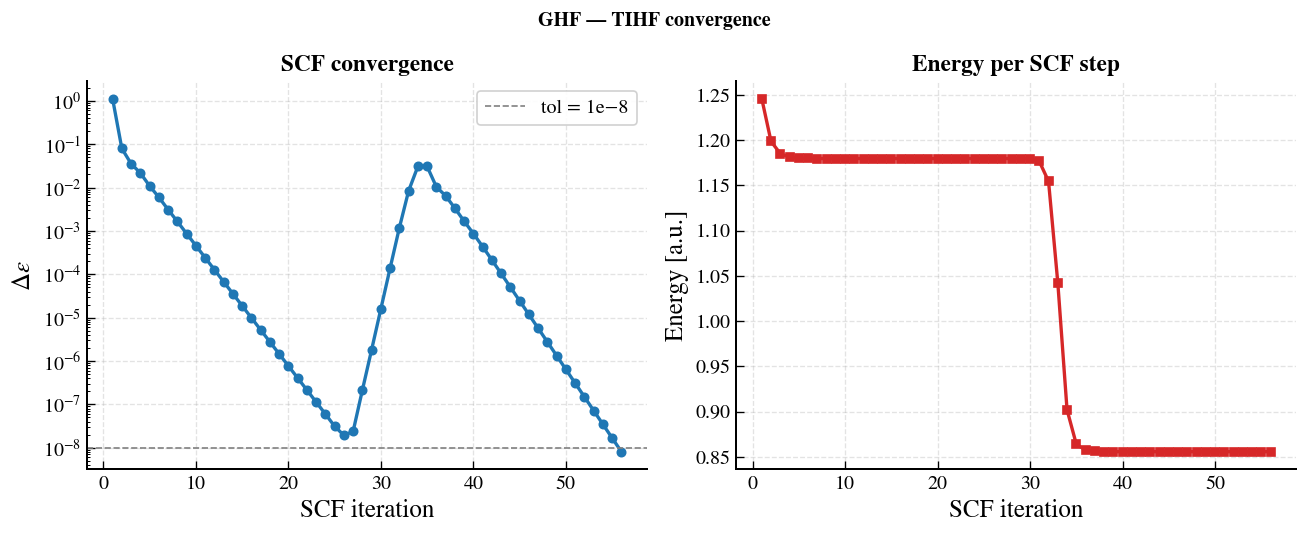

In [5]:
# SCF convergence diagnostic
ghf.plot_convergence(delta_per_step, eps_per_step)

## §5 — GHF: One-Body Density $\rho(x)$

The ground-state one-body density gives the probability of finding an electron
at position $x$, integrated over all other degrees of freedom.

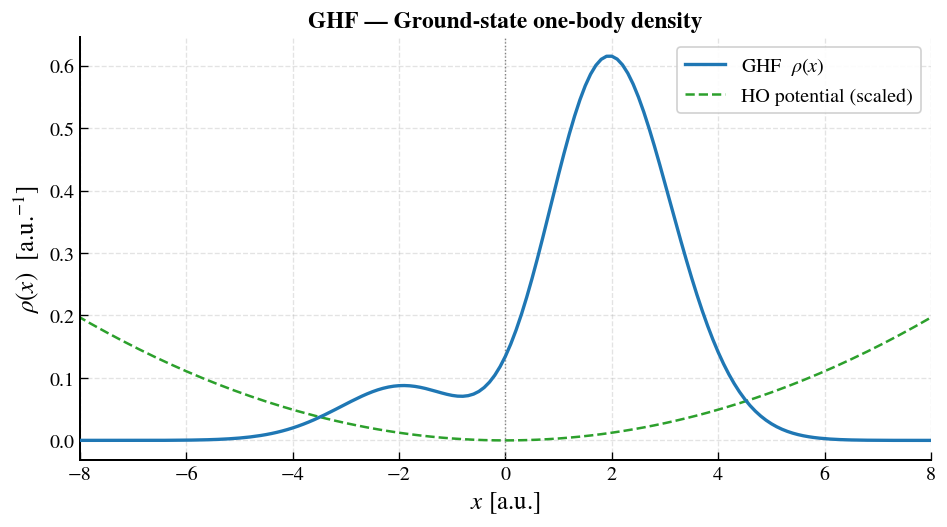

In [6]:
obd_ghf = ghf.eval_one_body_density(C0_ghf)
ghf.plot_one_body_density(obd_ghf, label='GHF  $\\rho(x)$')

## §6 — GHF: Short-Time TDHF Evolution (Laser On)

Propagate the system for one laser period $T = 2\pi/\Omega$ with the laser active.
The dipole moment and overlap with the initial state are recorded.

In [7]:
T_laser = 2 * np.pi / ghf.Omega   # one trap period

C_ghf, time_ghf, overlap_ghf, dipole_ghf, energy_ghf = ghf.solve_TDHF(
    tstart=0, dt=1e-3, t_max=T_laser, C0=C0_ghf,
    eval_overlap=True, eval_dipole=True, eval_energy=True,
    laser_ON=True)

print(f'Final time: {time_ghf[-1]:.4f} a.u.  ({time_ghf[-1]/T_laser:.2f} T)')

Final time: 25.1320 a.u.  (1.00 T)


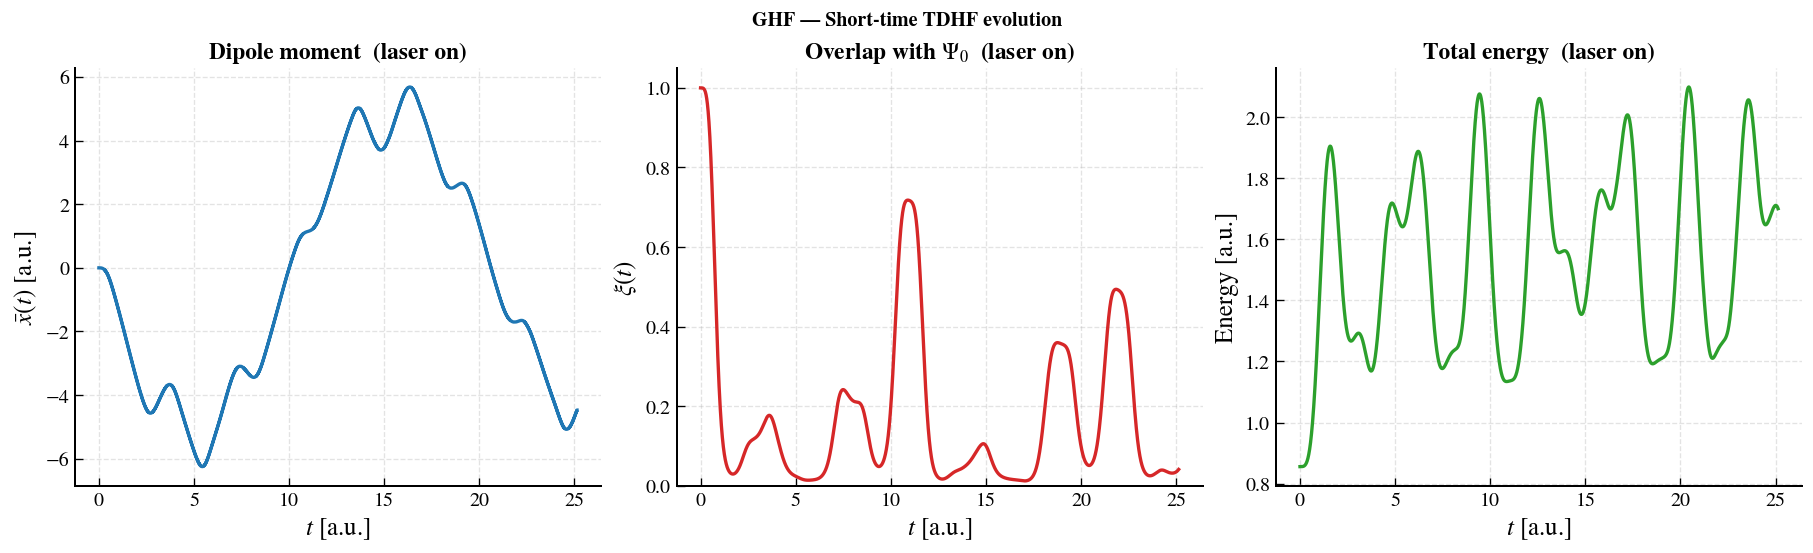

In [8]:
# Plot short-time results
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

axes[0].plot(time_ghf, dipole_ghf.real, color=C0_CLR)
axes[0].set(xlabel=r'$t$ [a.u.]', ylabel=r'$\bar{x}(t)$ [a.u.]',
            title='Dipole moment  (laser on)')
axes[0].grid(True)

axes[1].plot(time_ghf, overlap_ghf.real, color=C1_CLR)
axes[1].set(xlabel=r'$t$ [a.u.]', ylabel=r'$\xi(t)$',
            title='Overlap with $\\Psi_0$  (laser on)', ylim=(0, 1.05))
axes[1].grid(True)

axes[2].plot(time_ghf, energy_ghf.real, color=C2_CLR)
axes[2].set(xlabel=r'$t$ [a.u.]', ylabel='Energy [a.u.]',
            title='Total energy  (laser on)')
axes[2].grid(True)

fig.suptitle('GHF — Short-time TDHF evolution', fontweight='bold')
plt.show()

## §7 — GHF: Fourier Analysis (Laser On → Off)

The laser is active for $t \in [0, t_{\rm off}]$, then switched off.
The FFT of the free-evolution dipole and overlap signals reveals the
natural frequencies of the correlated system.
Vertical grey dotted lines mark multiples of $\omega$ (harmonic positions).

TDHF progress: 99.9%

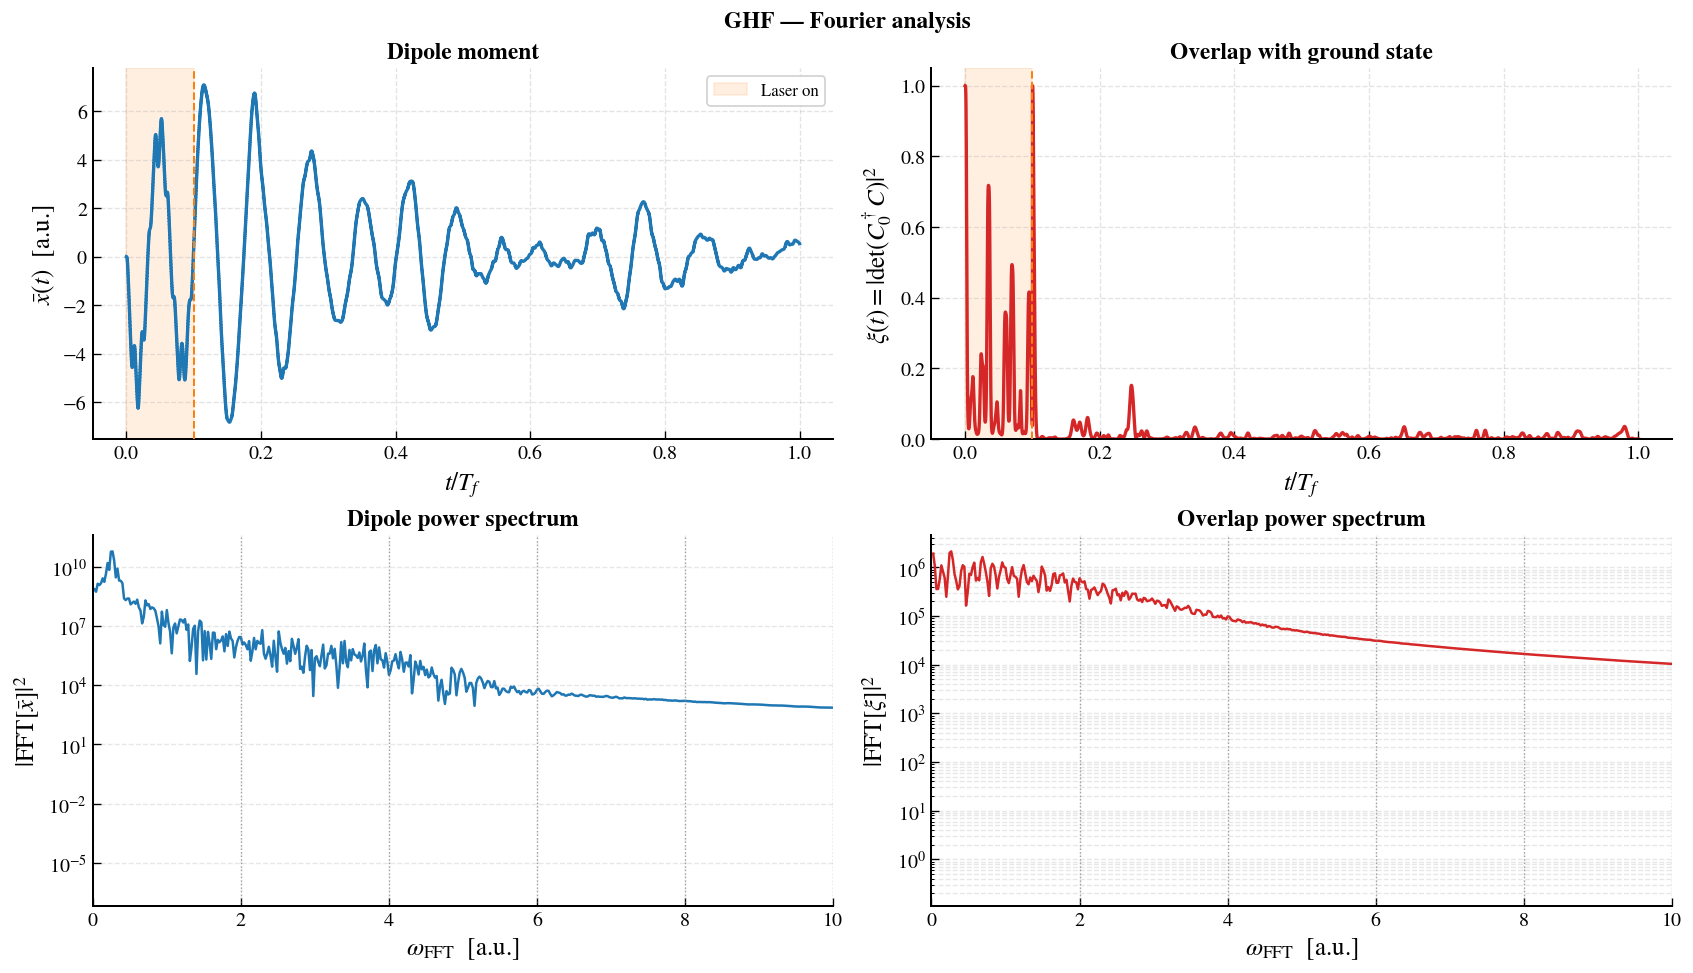

In [9]:
t_off = 10 * np.pi    # laser switch-off time
t_max_fourier = 100 * np.pi

(C2_ghf, time_fa, dipole_fa, overlap_fa,
 xFFT, xfreqFFT, overlapFFT, overlapfreqFFT, _) = ghf.fourier_analysis(
    tolerance=1e-8, max_iter=200,
    t_laser_ON=t_off, t_max=t_max_fourier, dt=1e-3,
    eval_energy=False)

ghf.plot_fourier_analysis(
    time_fa, dipole_fa, overlap_fa,
    xFFT, xfreqFFT, overlapFFT, overlapfreqFFT,
    t_laser_ON=t_off)

## §8 — RHF: Ground State (TIHF)

Repeat the SCF calculation in the **restricted** spin representation.
RHF uses spatial orbitals with double occupation; the Fock matrix
carries explicit Coulomb ($2J$) and exchange ($-K$) terms.

In [10]:
rhf = RHF(l=l, grid_length=grid_length, num_grid_points=num_grid_points,
          alpha=alpha, a=a, Omega=Omega, omega=omega, epsilon0=epsilon0,
          nparticles=nparticles)

epsilon_rhf, C0_rhf, eps_per_step_rhf, delta_per_step_rhf = rhf.solve_TIHF(
    tolerance=1e-8, max_iter=200,
    print_ON=True,
    eval_energy_per_step=True,
    eval_delta_per_step=True)

E_rhf = rhf.eval_total_energy(C0_rhf)
print(f'RHF ground-state energy: {E_rhf.real:.8f} a.u.')
print(f'Orbital energies: {epsilon_rhf[:int(nparticles/2)]}')

Converged after 27 iterations  (ΔE = 8.81e-09)
RHF ground-state energy: 1.17957129 a.u.
Orbital energies: [0.98691029]


In [ ]:
rhf.plot_convergence(delta_per_step_rhf, eps_per_step_rhf)

## §9 — RHF: One-Body Density

The RHF one-body density carries a factor of 2 (spin degeneracy).
Overlaying GHF and RHF densities on the same axes lets us compare the two
spin representations.

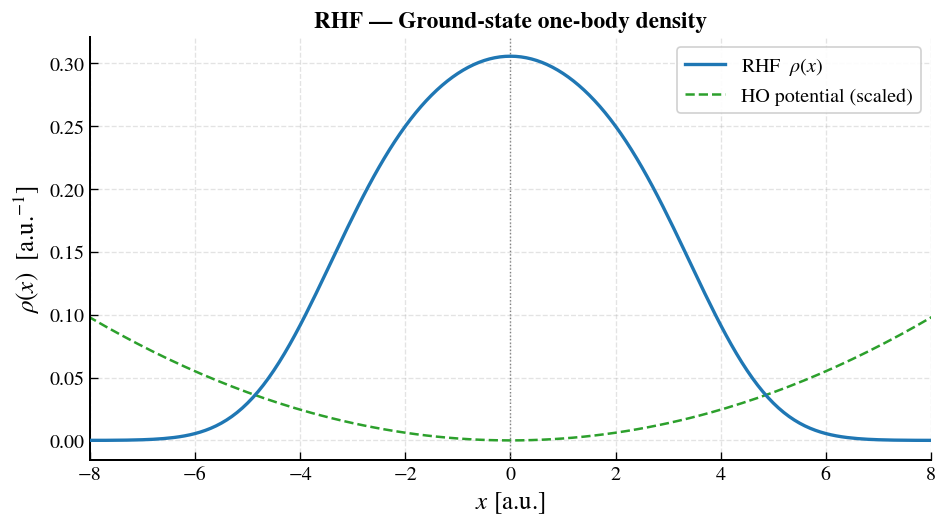

In [11]:
obd_rhf = rhf.eval_one_body_density(C0_rhf)

# Individual RHF plot
rhf.plot_one_body_density(obd_rhf, label='RHF  $\\rho(x)$')

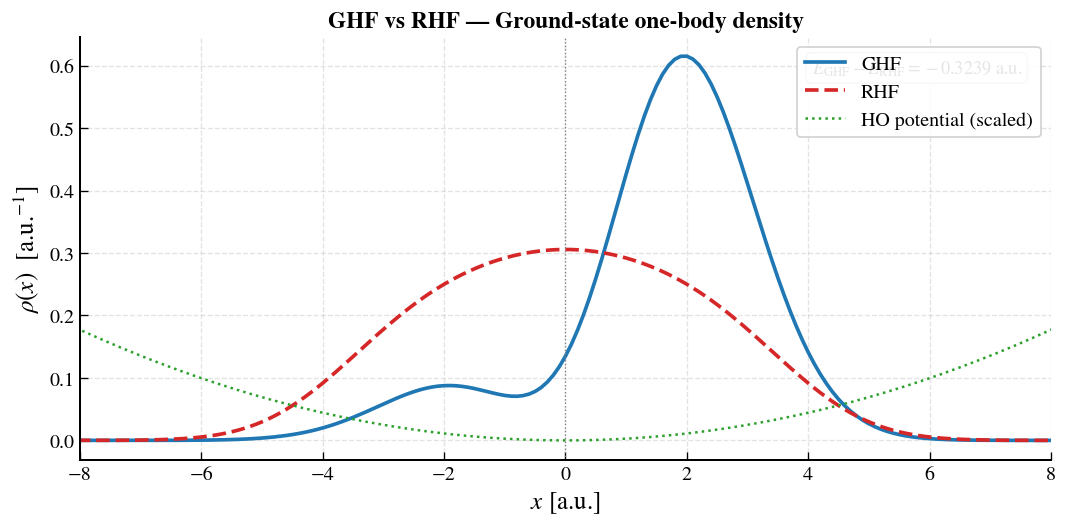

In [12]:
# ── Side-by-side GHF vs RHF comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(ghf.system.grid, obd_ghf.real, color=C0_CLR, label='GHF', lw=2.2)
ax.plot(rhf.system.grid, obd_rhf.real, color=C1_CLR, label='RHF',
        ls='--', lw=2.2)

# Scaled HO potential for reference
x = ghf.system.grid
pot = ghf.potential(x)
scale = obd_ghf.real.max() * 0.45 / pot.max()
ax.plot(x, pot * scale, color=C2_CLR, ls=':', lw=1.5,
        label=r'HO potential (scaled)')

ax.set(xlabel=r'$x$ [a.u.]',
       ylabel=r'$\rho(x)$  [a.u.$^{-1}$]',
       title='GHF vs RHF — Ground-state one-body density',
       xlim=(-8, 8))
ax.axvline(0, color='grey', lw=0.8, ls=':')
ax.legend()
ax.grid(True)

E_diff = (E_ghf - E_rhf).real
ax.annotate(f'$E_{{\\rm GHF}} - E_{{\\rm RHF}} = {E_diff:.4f}$ a.u.',
            xy=(0.97, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.7', lw=0.8))

plt.tight_layout()
plt.show()